# **ADNI Multi-Table Pipeline - Feature Importance on Top 15**

In [ ]:
# =========================
# ADNI Multi-Table Pipeline (Top 15 Feature Importance)
# =========================

# Objectives:
# - Load and merge all provided ADNI tables into a single visit-level dataset
# - Clean keys (RID + VISCODE), consolidate PTDEMOG to 1 row/RID, and build APOE features
# - Split by RID BEFORE any transformations (to avoid leakage)
# - Drop high-missingness columns using TRAIN ONLY
# - Prepare a preprocessing pipeline for structured data
# - Produce the processed 111-feature dataset
# - Retrain an ML model on the 111-feature dataset
# - Perform feature importance analysis
# - Select the top 15 most important features
# - Train and evaluate a model using the 15 selected features
# - Save/export downloadable datasets and artifacts

# Outputs:
# - Processed 111-feature datasets
# - Top-15-feature datasets
# - Trained models and feature importance tables
# - Downloadable CSV files

In [ ]:
# -------------------------
# 0.1) Manual Library Installation
# -------------------------

!pip install catboost
!pip install pgmpy

In [ ]:
# -------------------------
# 0.2) Imports and Libraries
# -------------------------

import re
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.decomposition import PCA
import xgboost as xgb
from catboost import CatBoostClassifier
from google.colab import files

from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import joblib

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# -------------------------
# 0.3) Architecture Configuration
# -------------------------

RANDOM_STATE = 42

MISSINGNESS_THRESHOLD = 0.45

# Split ratios: 70 / 15 / 15 (train / val / test), but split BY RID (group split)
TEST_VAL_TOTAL = 0.30
VAL_IN_TEMP = 0.50

# File paths (adjust if needed)
PATH_ADNIMERGE = "ADNIMERGE_10Nov2025.csv"
PATH_CDR       = "Dementia_Rating.csv"
PATH_DIAG      = "Diagnositic_Summary.csv"
PATH_COG       = "Cognitive_Scores.csv"
PATH_PTDEMOG   = "PTDEMOG_10Nov2025.csv"
PATH_APOE      = "ApoE_Genotyping.csv"

In [ ]:
# -------------------------
# 1) Model Helpers
# -------------------------

def _to_str(x):
    if pd.isna(x):
        return np.nan
    return str(x)

def normalize_viscode(series: pd.Series) -> pd.Series:
    """
    Standardize visit code strings for safer joins.
    Keeps baseline-like tokens; lowercases; trims whitespace.
    """
    s = series.astype("string").str.strip().str.lower()
    # common normalizations
    s = s.str.replace(r"\s+", "", regex=True)
    return s

def build_join_viscode(df: pd.DataFrame) -> pd.Series:
    """
    Creates VISCODE_JOIN:
    - Prefer VISCODE if exists and non-null
    - Else fall back to VISCODE2 if exists
    """
    vis = pd.Series([np.nan] * len(df), index=df.index, dtype="string")
    if "VISCODE" in df.columns:
        vis = normalize_viscode(df["VISCODE"])  # Use VISCODE first.
    if "VISCODE2" in df.columns:
        vis2 = normalize_viscode(df["VISCODE2"])  # Use VISCODE2 as backup.
        vis = vis.fillna(vis2)  # Fill only missing visit codes.
    return vis

def safe_to_datetime(df: pd.DataFrame, col: str) -> None:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")  # Invalid dates become NaT.

def parse_vismonth_from_viscode(viscode: pd.Series) -> pd.Series:
    """
    Extracts numeric month index from common ADNI visit codes.
    Examples:
      m06 -> 6, m12 -> 12, bl/sc -> 0
    Non-m patterns become NaN.
    """
    s = viscode.astype("string").str.lower()
    out = pd.Series([np.nan] * len(s), index=s.index, dtype="float")

    # baseline-ish
    out = out.mask(s.isin(["bl", "sc", "scr", "screen", "screening", "init", "m00"]), 0)

    # mXX
    m = s.str.extract(r"^m(\d+)$")[0]
    out = out.mask(m.notna(), m.astype(float))  # Convert mXX to month number.

    return out

def clean_dx_labels(dx: pd.Series) -> pd.Series:
    """
    Normalize diagnosis labels to a consistent set.
    Keeps: CN, MCI, Dementia
    """
    s = dx.astype("string").str.strip().str.upper()

    mapping = {
        "NORMAL": "CN",
        "NC": "CN",
        "CN": "CN",
        "COGNITIVELY NORMAL": "CN",

        "MCI": "MCI",
        "EMCI": "MCI",
        "LMCI": "MCI",

        "AD": "DEMENTIA",
        "ALZHEIMER'S DISEASE": "DEMENTIA",
        "DEMENTIA": "DEMENTIA",
    }
    s = s.replace(mapping)  # Map raw labels to standard classes.

    # unify case for final
    s = s.replace({"DEMENTIA": "Dementia", "MCI": "MCI", "CN": "CN"})

    # keep only these three classes (drop everything else to keep task clean)
    s = s.where(s.isin(["CN", "MCI", "Dementia"]), np.nan)  # Drop unknown labels.
    return s

def mode_label(x: pd.Series):
    x = x.dropna()  # Ignore missing values.
    if len(x) == 0:
        return np.nan
    return x.value_counts().idxmax()  # Return most frequent label.

def first_non_null(series: pd.Series):
    s = series.dropna()  # Keep non-missing values only.
    return s.iloc[0] if len(s) else np.nan

def consolidate_ptdemog_to_dim_subject(ptdemog: pd.DataFrame) -> pd.DataFrame:
    """
    PTDEMOG has multiple rows per RID (multi-phase). Consolidate to 1 row per RID.
    Strategy:
      - If update_stamp exists: sort DESC (latest), then take first non-null per column
      - Else: take first non-null per column without sorting
    """
    df = ptdemog.copy()

    if "RID" not in df.columns:
        raise ValueError("PTDEMOG must contain RID.")

    # parse update_stamp if present
    if "update_stamp" in df.columns:
        safe_to_datetime(df, "update_stamp")
        df = df.sort_values(["RID", "update_stamp"], ascending=[True, False])  # Latest rows first.
    else:
        df = df.sort_values(["RID"])  # Keep RID order stable.

    # choose a conservative set of demographic columns if present (keep others too)
    agg_dict = {c: first_non_null for c in df.columns if c != "RID"}  # Aggregate each column safely.
    dim = df.groupby("RID", as_index=False).agg(agg_dict)
    # we'll aggregate ALL columns, but you can restrict if desired.

    return dim

def build_apoe_features(apoe: pd.DataFrame) -> pd.DataFrame:
    """
    Create APOE4_count and APOE4_carrier from GENOTYPE.
    """
    df = apoe.copy()
    if "RID" not in df.columns:
        raise ValueError("ApoE_Genotyping must contain RID.")
    if "GENOTYPE" not in df.columns:
        # If genotype isn't present, still return RID unique rows
        out = df[["RID"]].drop_duplicates().copy()
        out["APOE4_count"] = np.nan
        out["APOE4_carrier"] = np.nan
        return out

    gt = df["GENOTYPE"].astype("string").str.strip()
    # count of '4' alleles in strings like '3/4', '4/4'
    apoe4_count = gt.str.findall("4").apply(lambda lst: len(lst) if isinstance(lst, list) else np.nan)
    df["APOE4_count"] = apoe4_count.astype("float")
    df["APOE4_carrier"] = (df["APOE4_count"] >= 1).astype("float")  # Mark carriers of at least one APOE4.

    # one row per RID (keep first non-null)
    df = df.sort_values(["RID"])
    out = df.groupby("RID", as_index=False).agg({
        "GENOTYPE": first_non_null,
        "APOE4_count": first_non_null,
        "APOE4_carrier": first_non_null
    })
    return out

def drop_leaky_columns(df: pd.DataFrame, target_col: str = "DX_CLEAN") -> pd.DataFrame:
    """
    Remove columns that directly encode diagnosis labels or are label-derived.
    Keeps the target_col (default DX_CLEAN).
    """
    df = df.copy()

    # Exact leaky columns to drop (but keep target_col)
    leaky_exact = {
        "DIAGNOSIS", "PHC_Diagnosis",
        "DX_bl", "DXCHANGE"
    }

    to_drop = []
    for c in df.columns:
        cup = str(c).upper()

        # keep target, always
        if c == target_col:
            continue

        # drop exact known label-derived cols
        if c in leaky_exact:
            to_drop.append(c)
            continue

        # drop diagnostic-summary DX* flags like DXNORM, DXMCI, DXAD, DXCONFID, etc.
        # but DO NOT drop plain "DX" here (you may want it for audit; you'll drop it later from features anyway)
        if cup.startswith("DX") and c != "DX" and c != target_col:
            # Example matches: DXNORM, DXMCI, DXDEP, DXPARK, DXCONFID...
            to_drop.append(c)

    to_drop = [c for c in to_drop if c in df.columns]  # Drop only existing columns.
    return df.drop(columns=to_drop, errors="ignore")

def make_onehot_encoder():
    """
    Compatibility for sklearn versions:
      - newer: OneHotEncoder(sparse_output=False)
      - older: OneHotEncoder(sparse=False)
    """
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown="ignore")  # Fallback for older sklearn.

In [ ]:
# -------------------------
# 2) Loading all datasets
# -------------------------

adni = pd.read_csv(PATH_ADNIMERGE, low_memory=False)
cdr  = pd.read_csv(PATH_CDR, low_memory=False)
diag = pd.read_csv(PATH_DIAG, low_memory=False)
cog  = pd.read_csv(PATH_COG, low_memory=False)
ptd  = pd.read_csv(PATH_PTDEMOG, low_memory=False)
apoe = pd.read_csv(PATH_APOE, low_memory=False)

# Normalize RID type where possible
for df in [adni, cdr, diag, cog, ptd, apoe]:
    if "RID" in df.columns:
        df["RID"] = pd.to_numeric(df["RID"], errors="coerce").astype("Int64")

# Normalize visit codes into a common join column
for df in [adni, cdr, diag, cog]:
    df["VISCODE_JOIN"] = build_join_viscode(df)

# Parse date columns if present (useful for audit / feature engineering)
for col in ["EXAMDATE", "VISDATE", "update_stamp", "APTESTDT"]:
    safe_to_datetime(adni, col)
    safe_to_datetime(cdr, col)
    safe_to_datetime(diag, col)
    safe_to_datetime(cog, col)
    safe_to_datetime(ptd, col)
    safe_to_datetime(apoe, col)

# Optional QC filtering (CDR has HAS_QC_ERROR)
if "HAS_QC_ERROR" in cdr.columns:
    cdr = cdr[cdr["HAS_QC_ERROR"].fillna(0).astype(int) == 0].copy()

# Ensure uniqueness on (RID, VISCODE_JOIN) for visit-level tables (keep first if duplicates)
def dedup_visit_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if "RID" not in df.columns or "VISCODE_JOIN" not in df.columns:
        return df
    df2 = df.copy()
    df2 = df2.sort_values(["RID", "VISCODE_JOIN"])
    df2 = df2.drop_duplicates(subset=["RID", "VISCODE_JOIN"], keep="first")
    return df2

adni = dedup_visit_table(adni, "ADNIMERGE")
cdr  = dedup_visit_table(cdr,  "Dementia_Rating")
diag = dedup_visit_table(diag, "Diagnositic_Summary")
cog  = dedup_visit_table(cog,  "Cognitive_Scores")

# Consolidate PTDEMOG to dim_subject (1 row per RID)
dim_subject = consolidate_ptdemog_to_dim_subject(ptd)

# Build APOE features (1 row per RID)
dim_genetics = build_apoe_features(apoe)

In [ ]:
# -------------------------
# 3) Build merged RAW dataset (anchored on ADNIMERGE visit facts)
# -------------------------

# Normalize target DX
if "DX" not in adni.columns:
    raise ValueError("ADNIMERGE must contain DX as the target label.")
adni["DX_CLEAN"] = clean_dx_labels(adni["DX"])

# Keep only rows with valid target
adni_clean = adni.dropna(subset=["DX_CLEAN", "RID", "VISCODE_JOIN"]).copy()

# Add a useful numeric visit-month feature
adni_clean["VISMONTH"] = parse_vismonth_from_viscode(adni_clean["VISCODE_JOIN"])

# Merge visit-level add-ons (left join so we keep ADNIMERGE backbone)
merged = adni_clean.merge(
    cdr.drop(columns=["VISCODE", "VISCODE2"], errors="ignore"),
    on=["RID", "VISCODE_JOIN"],
    how="left",
    suffixes=("", "_cdr")
)

merged = merged.merge(
    diag.drop(columns=["VISCODE", "VISCODE2"], errors="ignore"),
    on=["RID", "VISCODE_JOIN"],
    how="left",
    suffixes=("", "_diag")
)

merged = merged.merge(
    cog.drop(columns=["VISCODE", "VISCODE2"], errors="ignore"),
    on=["RID", "VISCODE_JOIN"],
    how="left",
    suffixes=("", "_cog")
)

# Merge subject dimensions (RID only)
merged = merged.merge(dim_subject, on="RID", how="left", suffixes=("", "_ptd"))
merged = merged.merge(dim_genetics, on="RID", how="left", suffixes=("", "_apoe"))

# Drop obvious label-leakage columns coming from other tables
merged = drop_leaky_columns(merged, target_col="DX_CLEAN")

# Save raw merged for auditing
merged.to_csv("merged_adni_raw.csv", index=False)

print("Merged raw shape:", merged.shape)
print("Class distribution (DX_CLEAN):")
print(merged["DX_CLEAN"].value_counts())

Merged raw shape: (11458, 260)
Class distribution (DX_CLEAN):
DX_CLEAN
MCI         4989
CN          4020
Dementia    2449
Name: count, dtype: Int64


In [ ]:
# -------------------------
# 4) Split by RID BEFORE transformations (no leakage)
# -------------------------

target = "DX_CLEAN"

# Define X/y, keep RID for grouping then drop from features later
X_all = merged.copy()
y_all = X_all[target].copy()

# Build group-level label for stratification (mode across visits)
group_labels = (
    pd.DataFrame({"RID": X_all["RID"], "y": y_all})
    .dropna()
    .groupby("RID")["y"]
    .agg(mode_label)
    .dropna()
)

rids = group_labels.index.astype("int")
rid_y = group_labels.values

# 1) RID split: train vs temp
rid_train, rid_temp = train_test_split(
    rids,
    test_size=TEST_VAL_TOTAL,
    random_state=RANDOM_STATE,
    stratify=rid_y
)

# 2) temp -> val + test
# Need stratify for temp too
temp_labels = pd.Series(rid_y, index=rids).loc[rid_temp].values
rid_val, rid_test = train_test_split(
    rid_temp,
    test_size=VAL_IN_TEMP,
    random_state=RANDOM_STATE,
    stratify=temp_labels
)

# Now create row-level splits by RID membership
train_mask = X_all["RID"].isin(rid_train)
val_mask   = X_all["RID"].isin(rid_val)
test_mask  = X_all["RID"].isin(rid_test)

X_train = X_all.loc[train_mask].copy()
y_train = y_all.loc[train_mask].copy()

X_val = X_all.loc[val_mask].copy()
y_val = y_all.loc[val_mask].copy()

X_test = X_all.loc[test_mask].copy()
y_test = y_all.loc[test_mask].copy()

print("\nRow-level split sizes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

print("\nRID-level split sizes:")
print("Train RIDs:", len(rid_train), "Val RIDs:", len(rid_val), "Test RIDs:", len(rid_test))


Row-level split sizes:
Train: (8004, 260) Val: (1714, 260) Test: (1740, 260)

RID-level split sizes:
Train RIDs: 1686 Val RIDs: 361 Test RIDs: 362


In [ ]:
# -------------------------
# 5) Drop columns with high missingness (TRAIN ONLY)
#    (Threshold > 0.30 | using 0.45)
# -------------------------

# Remove target + high-leak identifiers from features
IDENTIFIER_COLS = [
    "DX", "DX_CLEAN", "RID", "PTID", "VISCODE", "VISCODE2", "VISCODE_JOIN",
    "EXAMDATE", "VISDATE", "update_stamp", "APTESTDT"
]

X_train_feat = X_train.drop(columns=[c for c in IDENTIFIER_COLS if c in X_train.columns], errors="ignore")
X_val_feat   = X_val.drop(columns=[c for c in IDENTIFIER_COLS if c in X_val.columns], errors="ignore")
X_test_feat  = X_test.drop(columns=[c for c in IDENTIFIER_COLS if c in X_test.columns], errors="ignore")

# Compute missingness on TRAIN ONLY
missing_rates = X_train_feat.isna().mean()
cols_to_drop = missing_rates[missing_rates > MISSINGNESS_THRESHOLD].index.tolist()

X_train_feat = X_train_feat.drop(columns=cols_to_drop)
X_val_feat   = X_val_feat.drop(columns=cols_to_drop, errors="ignore")
X_test_feat  = X_test_feat.drop(columns=cols_to_drop, errors="ignore")

print("\nDropped columns due to missingness >", MISSINGNESS_THRESHOLD, ":", len(cols_to_drop))
print("Feature shapes after dropping:", X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)


Dropped columns due to missingness > 0.45 : 139
Feature shapes after dropping: (8004, 111) (1714, 111) (1740, 111)


In [ ]:
# -------------------------
# 6) Preprocessing pipeline for structured data
# -------------------------

# Detect numeric vs categorical columns
numeric_cols = X_train_feat.select_dtypes(include=[np.number]).columns.tolist()  # Select numeric columns.
categorical_cols = [c for c in X_train_feat.columns if c not in numeric_cols]  # Remaining are categorical.

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# ---- Numeric Preprocessing:

num_imputer = SimpleImputer(strategy="median")  # Fill missing numeric values with median.

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_train_feat.index
)
X_val_num = pd.DataFrame(
    num_imputer.transform(X_val_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_val_feat.index
)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_test_feat.index
)

# Split numeric columns into skewed vs regular (based on TRAIN ONLY AFTER IMPUTATION)
skewed_numeric_cols = []
regular_numeric_cols = []

for col in numeric_cols:
    skew_val = X_train_num[col].skew()  # Compute skewness on training data.
    if pd.notna(skew_val) and abs(skew_val) > 1:
        skewed_numeric_cols.append(col)  # Highly skewed features.
    else:
        regular_numeric_cols.append(col)  # Normal distribution features.

print("Skewed numeric columns:", len(skewed_numeric_cols))
print("Regular numeric columns:", len(regular_numeric_cols))

# Power transform only skewed numeric columns
if len(skewed_numeric_cols) > 0:
    power_transformer = PowerTransformer(method="yeo-johnson", standardize=False)  # Normalize skewed distributions.

    X_train_num.loc[:, skewed_numeric_cols] = power_transformer.fit_transform(X_train_num[skewed_numeric_cols])
    X_val_num.loc[:, skewed_numeric_cols] = power_transformer.transform(X_val_num[skewed_numeric_cols])
    X_test_num.loc[:, skewed_numeric_cols] = power_transformer.transform(X_test_num[skewed_numeric_cols])

# Scale all numeric columns
scaler = StandardScaler()  # Standardize features (mean=0, std=1).

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=numeric_cols,
    index=X_train_num.index
)
X_val_num_scaled = pd.DataFrame(
    scaler.transform(X_val_num),
    columns=numeric_cols,
    index=X_val_num.index
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=numeric_cols,
    index=X_test_num.index
)

# ---- Categorical Preprocessing:

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")  # Fill missing categorical values with mode.

    X_train_cat = pd.DataFrame(
        cat_imputer.fit_transform(X_train_feat[categorical_cols]),
        columns=categorical_cols,
        index=X_train_feat.index
    )
    X_val_cat = pd.DataFrame(
        cat_imputer.transform(X_val_feat[categorical_cols]),
        columns=categorical_cols,
        index=X_val_feat.index
    )
    X_test_cat = pd.DataFrame(
        cat_imputer.transform(X_test_feat[categorical_cols]),
        columns=categorical_cols,
        index=X_test_feat.index
    )

    # Ordinal encoding instead of one-hot encoding (safe for unseen values)
    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_cat_enc = pd.DataFrame(
        ordinal_encoder.fit_transform(X_train_cat.astype(str)),
        columns=categorical_cols,
        index=X_train_cat.index
    )
    X_val_cat_enc = pd.DataFrame(
        ordinal_encoder.transform(X_val_cat.astype(str)),
        columns=categorical_cols,
        index=X_val_cat.index
    )
    X_test_cat_enc = pd.DataFrame(
        ordinal_encoder.transform(X_test_cat.astype(str)),
        columns=categorical_cols,
        index=X_test_cat.index
    )
else:
    X_train_cat_enc = pd.DataFrame(index=X_train_feat.index)  # Empty if no categorical features.
    X_val_cat_enc = pd.DataFrame(index=X_val_feat.index)
    X_test_cat_enc = pd.DataFrame(index=X_test_feat.index)

# Combine processed numeric + categorical
X_train_processed = pd.concat([X_train_num_scaled, X_train_cat_enc], axis=1)  # Merge all features.
X_val_processed = pd.concat([X_val_num_scaled, X_val_cat_enc], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat_enc], axis=1)

# Ensure same column order
final_cols = X_train_processed.columns.tolist()
X_val_processed = X_val_processed.reindex(columns=final_cols, fill_value=0)  # Align columns with train.
X_test_processed = X_test_processed.reindex(columns=final_cols, fill_value=0)

print("\nProcessed feature shapes:")
print("Train:", X_train_processed.shape)
print("Val:  ", X_val_processed.shape)
print("Test: ", X_test_processed.shape)


Numeric columns: 88
Categorical columns: 23
Skewed numeric columns: 53
Regular numeric columns: 35

Processed feature shapes:
Train: (8004, 111)
Val:   (1714, 111)
Test:  (1740, 111)


In [ ]:
# -------------------------
# 7) Save the processed 111-feature dataset
# -------------------------

y_train_df = pd.DataFrame({"DX_CLEAN": y_train.values}, index=X_train_processed.index)  # Attach labels to train set.
y_val_df   = pd.DataFrame({"DX_CLEAN": y_val.values}, index=X_val_processed.index)  # Attach labels to validation set.
y_test_df  = pd.DataFrame({"DX_CLEAN": y_test.values}, index=X_test_processed.index)  # Attach labels to test set.

train_111 = pd.concat([X_train_processed, y_train_df], axis=1)  # Combine features and labels for train.
val_111   = pd.concat([X_val_processed, y_val_df], axis=1)  # Combine features and labels for validation.
test_111  = pd.concat([X_test_processed, y_test_df], axis=1)  # Combine features and labels for test.

full_111 = pd.concat(
    [
        train_111.assign(split="train"),  # Tag train rows.
        val_111.assign(split="val"),  # Tag validation rows.
        test_111.assign(split="test")  # Tag test rows.
    ],
    axis=0
)

train_111.to_csv("adni_train_111_features.csv", index=False)  # Save train dataset.
val_111.to_csv("adni_val_111_features.csv", index=False)  # Save validation dataset.
test_111.to_csv("adni_test_111_features.csv", index=False)  # Save test dataset.
full_111.to_csv("adni_full_111_features.csv", index=False)  # Save combined dataset.

print("\nSaved processed datasets:")
print("- adni_train_111_features.csv")
print("- adni_val_111_features.csv")
print("- adni_test_111_features.csv")
print("- adni_full_111_features.csv")


Saved processed datasets:
- adni_train_111_features.csv
- adni_val_111_features.csv
- adni_test_111_features.csv
- adni_full_111_features.csv


In [ ]:
# -------------------------
# 8) Retrain ML model on the processed 111-feature dataset
# -------------------------

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)  # Encode training labels.
y_val_enc   = label_encoder.transform(y_val)  # Encode validation labels.
y_test_enc  = label_encoder.transform(y_test)  # Encode test labels.

def make_xgb_safe_feature_names(columns):
    cleaned = []
    seen = {}

    for col in columns:
        col = str(col)

        # XGBoost does not allow [, ], <
        col = col.replace("[", "_")
        col = col.replace("]", "_")
        col = col.replace("<", "_lt_")

        # Clean other potentially problematic characters
        col = col.replace(">", "_gt_")
        col = col.replace(" ", "_")
        col = col.replace(",", "_")
        col = col.replace(":", "_")
        col = col.replace(";", "_")
        col = col.replace("/", "_")
        col = col.replace("\\", "_")
        col = col.replace("(", "_")
        col = col.replace(")", "_")
        col = col.replace("{", "_")
        col = col.replace("}", "_")
        col = col.replace("=", "_")
        col = col.replace("-", "_")
        col = col.replace(".", "_")
        col = re.sub(r"_+", "_", col).strip("_")  # Collapse repeated underscores.

        if col == "":
            col = "feature"  # Ensure non-empty name.

        if col in seen:
            seen[col] += 1
            col = f"{col}_{seen[col]}"  # Make duplicate names unique.
        else:
            seen[col] = 0

        cleaned.append(col)

    return cleaned

safe_feature_names = make_xgb_safe_feature_names(X_train_processed.columns)  # Sanitize feature names.

X_train_processed = X_train_processed.copy()
X_val_processed = X_val_processed.copy()
X_test_processed = X_test_processed.copy()

X_train_processed.columns = safe_feature_names  # Apply safe names to train.
X_val_processed.columns = safe_feature_names  # Apply safe names to validation.
X_test_processed.columns = safe_feature_names  # Apply safe names to test.

xgb_model_111 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE
)

xgb_model_111.fit(X_train_processed, y_train_enc)  # Train XGBoost model.

val_pred_111 = xgb_model_111.predict(X_val_processed)  # Predict validation labels.
test_pred_111 = xgb_model_111.predict(X_test_processed)  # Predict test labels.

val_proba_111 = xgb_model_111.predict_proba(X_val_processed)  # Predict validation probabilities.
test_proba_111 = xgb_model_111.predict_proba(X_test_processed)  # Predict test probabilities.

print("\n=== Evaluation: 111-feature model ===")
print("Validation Accuracy:", accuracy_score(y_val_enc, val_pred_111))
print("Validation F1 (weighted):", f1_score(y_val_enc, val_pred_111, average="weighted"))
print("Test Accuracy:", accuracy_score(y_test_enc, test_pred_111))
print("Test F1 (weighted):", f1_score(y_test_enc, test_pred_111, average="weighted"))


=== Evaluation: 111-feature model ===
Validation Accuracy: 0.882730455075846
Validation F1 (weighted): 0.8830021603902652
Test Accuracy: 0.9091954022988505
Test F1 (weighted): 0.908849968462429


In [ ]:
# -------------------------
# 9.1) Feature importance analysis
# -------------------------

#Check Feature Correlations and

importance_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": xgb_model_111.feature_importances_  # Extract feature importance scores.
}).sort_values("importance", ascending=False).reset_index(drop=True)  # Sort features by importance.

importance_df.to_csv("feature_importance_111.csv", index=False)  # Save importance results.

print("\nTop 20 features:")
print(importance_df.head(20))  # Display top 20 most important features.

# drop PTADDX, Try once with and once without ORIGPROT
#Engineer
# PTCOGBEG → years since symptoms started
# VISDATE_ptd → years from baseline
# do not use feature number 16


Top 20 features:
            feature  importance
0             CDRSB    0.199698
1          CDRSB_bl    0.081774
2               FAQ    0.047972
3          PTCOGBEG    0.036677
4      mPACCtrailsB    0.026954
5          ORIGPROT    0.023338
6      LDELTOTAL_BL    0.020915
7     mPACCdigit_bl    0.019843
8            PTADDX    0.014268
9        mPACCdigit    0.014033
10          MMSE_bl    0.013627
11  mPACCtrailsB_bl    0.012170
12     FSVERSION_bl    0.009597
13      VISDATE_ptd    0.009447
14           ADAS13    0.009206
15        PHASE_ptd    0.008457
16     USERDATE_ptd    0.007995
17     PTGENDER_ptd    0.007861
18            APOE4    0.007752
19      APOE4_count    0.007641


In [ ]:
# -------------------------
# 9.2) Feature importance analysis (FIXED ALIGNMENT)
# -------------------------

import pandas as pd
import numpy as np

X_used = X_train_processed.copy()

feature_importances = xgb_model_111.feature_importances_

# sanity check
print("Features used in model:", len(feature_importances))
print("Columns in dataset:", X_used.shape[1])

if len(feature_importances) != X_used.shape[1]:
    raise ValueError(
        "Mismatch between trained model features and dataframe columns.\n"
        "You must compute feature importance BEFORE dropping or engineering columns."
    )

# build correct dataframe
importance_df = pd.DataFrame({
    "feature": X_used.columns,
    "importance": feature_importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

if "PTCOGBEG" in importance_df["feature"].values:
    print("Note: PTCOGBEG exists — should be interpreted as symptom duration proxy")

if "VISDATE_ptd" in importance_df["feature"].values:
    print("Note: VISDATE_ptd exists — temporal drift feature")

importance_df.to_csv("feature_importance_111.csv", index=False)

print("\nTop 20 features:")
print(importance_df.head(20))

Features used in model: 111
Columns in dataset: 111
Note: PTCOGBEG exists — should be interpreted as symptom duration proxy
Note: VISDATE_ptd exists — temporal drift feature

Top 20 features:
            feature  importance
0             CDRSB    0.199698
1          CDRSB_bl    0.081774
2               FAQ    0.047972
3          PTCOGBEG    0.036677
4      mPACCtrailsB    0.026954
5          ORIGPROT    0.023338
6      LDELTOTAL_BL    0.020915
7     mPACCdigit_bl    0.019843
8            PTADDX    0.014268
9        mPACCdigit    0.014033
10          MMSE_bl    0.013627
11  mPACCtrailsB_bl    0.012170
12     FSVERSION_bl    0.009597
13      VISDATE_ptd    0.009447
14           ADAS13    0.009206
15        PHASE_ptd    0.008457
16     USERDATE_ptd    0.007995
17     PTGENDER_ptd    0.007861
18            APOE4    0.007752
19      APOE4_count    0.007641


In [ ]:
# -------------------------
# 10) Select top 15 features
# -------------------------

top_15_features = importance_df.head(15)["feature"].tolist()  # Select top 15 most important features.
print("\nTop 15 selected features:")
print(top_15_features)

X_train_top15 = X_train_processed[top_15_features].copy()  # Subset train features.
X_val_top15   = X_val_processed[top_15_features].copy()  # Subset validation features.
X_test_top15  = X_test_processed[top_15_features].copy()  # Subset test features.

# Insert RID
X_train_top15.insert(0, "RID", X_train["RID"].values)
X_val_top15.insert(0, "RID", X_val["RID"].values)
X_test_top15.insert(0, "RID", X_test["RID"].values)

# Insert Visit / Exam Date
X_train_top15.insert(1, "EXAMDATE", X_train["EXAMDATE"].values)
X_val_top15.insert(1, "EXAMDATE", X_val["EXAMDATE"].values)
X_test_top15.insert(1, "EXAMDATE", X_test["EXAMDATE"].values)

# Save top-15 datasets
train_top15 = pd.concat([X_train_top15, y_train_df], axis=1)  # Combine train features and labels.
val_top15   = pd.concat([X_val_top15, y_val_df], axis=1)  # Combine validation features and labels.
test_top15  = pd.concat([X_test_top15, y_test_df], axis=1)  # Combine test features and labels.

full_top15 = pd.concat(
    [
        train_top15.assign(split="train"),  # Tag train rows.
        val_top15.assign(split="val"),  # Tag validation rows.
        test_top15.assign(split="test")  # Tag test rows.
    ],
    axis=0
)

train_top15.to_csv("adni_train_top15_features.csv", index=False)  # Save train dataset.
val_top15.to_csv("adni_val_top15_features.csv", index=False)  # Save validation dataset.
test_top15.to_csv("adni_test_top15_features.csv", index=False)  # Save test dataset.
full_top15.to_csv("adni_full_top15_features.csv", index=False)  # Save combined dataset.


Top 15 selected features:
['CDRSB', 'CDRSB_bl', 'FAQ', 'PTCOGBEG', 'mPACCtrailsB', 'ORIGPROT', 'LDELTOTAL_BL', 'mPACCdigit_bl', 'PTADDX', 'mPACCdigit', 'MMSE_bl', 'mPACCtrailsB_bl', 'FSVERSION_bl', 'VISDATE_ptd', 'ADAS13']


In [ ]:
# -------------------------
# 11) Confusion Matrix Plot
# -------------------------

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [ ]:
# -------------------------
# 12.1) Train and evaluate model using the 15 selected features
# -------------------------

xgb_model_top15 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE
)

xgb_model_top15.fit(
    X_train_top15.drop(columns=["RID", "EXAMDATE"]),
    y_train_enc
)

val_pred_top15 = xgb_model_top15.predict(
    X_val_top15.drop(columns=["RID", "EXAMDATE"])
)

test_pred_top15 = xgb_model_top15.predict(
    X_test_top15.drop(columns=["RID", "EXAMDATE"])
)

print("\n=== Evaluation: Top-15-feature model ===")
print("Validation Accuracy:", accuracy_score(y_val_enc, val_pred_top15))
print("Validation F1 (weighted):", f1_score(y_val_enc, val_pred_top15, average="weighted"))
print("Test Accuracy:", accuracy_score(y_test_enc, test_pred_top15))
print("Test F1 (weighted):", f1_score(y_test_enc, test_pred_top15, average="weighted"))

print("\nClassification Report (Test - Top 15):")
print(classification_report(
    y_test_enc,
    test_pred_top15,
    target_names=label_encoder.classes_
))  # Detailed per-class metrics.


=== Evaluation: Top-15-feature model ===
Validation Accuracy: 0.8891481913652275
Validation F1 (weighted): 0.8893125869008769
Test Accuracy: 0.9155172413793103
Test F1 (weighted): 0.9154308540697295

Classification Report (Test - Top 15):
              precision    recall  f1-score   support

          CN       0.93      0.94      0.94       608
    Dementia       0.91      0.90      0.90       364
         MCI       0.91      0.90      0.90       768

    accuracy                           0.92      1740
   macro avg       0.91      0.91      0.91      1740
weighted avg       0.92      0.92      0.92      1740



Fitting 5 folds for each of 25 candidates, totalling 125 fits

=== Best Random Search Params (Top-15) ===
{'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.07, 'gamma': 0, 'colsample_bytree': 0.7}

=== Best CV Score (ROC AUC OVR Weighted) ===
0.9872682677850108

=== Evaluation: Top-15 tuned model (Validation) ===
Accuracy: 0.882730455075846
F1 (weighted): 0.8830568690925974
F1 (macro): 0.8806103171102354
Balanced Accuracy: 0.8779343460869197
MCC: 0.8169068272447748
Log Loss: 0.36177298371083816
ROC AUC OVR (macro): 0.9673924527149537
ROC AUC OVR (weighted): 0.9636947735502135
ROC AUC OVO (macro): 0.968841161206218
ROC AUC OVO (weighted): 0.9668646806564928

Classification Report (Validation - Top 15 Tuned):
              precision    recall  f1-score   support

          CN       0.94      0.91      0.92       561
    Dementia       0.85      0.84      0.85       385
         MCI       0.86      0.89  

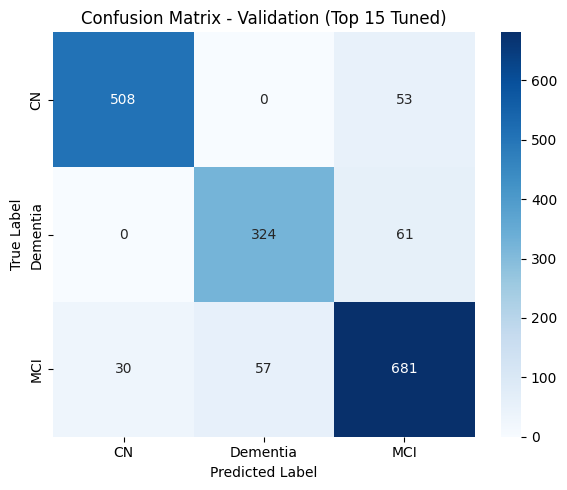


=== Evaluation: Top-15 tuned model (Test) ===
Accuracy: 0.9189655172413793
F1 (weighted): 0.9188842350748557
F1 (macro): 0.9180511337782992
Balanced Accuracy: 0.9192502490199859
MCC: 0.8734765495932316
Log Loss: 0.26418906224365096
ROC AUC OVR (macro): 0.9798874826758843
ROC AUC OVR (weighted): 0.978296601277987
ROC AUC OVO (macro): 0.980183201487041
ROC AUC OVO (weighted): 0.9793891759093523

Classification Report (Test - Top 15 Tuned):
              precision    recall  f1-score   support

          CN       0.93      0.95      0.94       608
    Dementia       0.90      0.91      0.91       364
         MCI       0.92      0.90      0.91       768

    accuracy                           0.92      1740
   macro avg       0.92      0.92      0.92      1740
weighted avg       0.92      0.92      0.92      1740

Confusion Matrix (Test - Top 15 Tuned):
[[576   0  32]
 [  1 331  32]
 [ 40  36 692]]


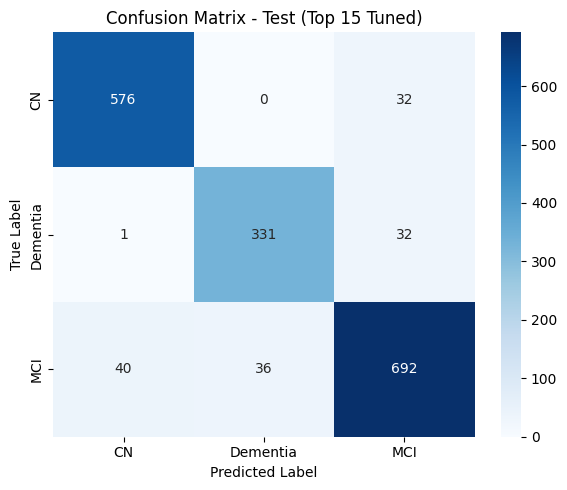

In [ ]:
# -------------------------
# 12.2) Tune and evaluate model using the 15 selected features
# -------------------------

# Base XGBoost model
xgb_model_top15_base = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

# Random search space
param_dist = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0]
}

# CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Multiple scoring metrics for tuning confirmation
scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc_ovr_weighted": "roc_auc_ovr_weighted"
}

random_search_top15 = RandomizedSearchCV(
    estimator=xgb_model_top15_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring=scoring,
    refit="roc_auc_ovr_weighted",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_top15.fit(
    X_train_top15.drop(columns=["RID", "EXAMDATE"]),
    y_train_enc
)

# Best model
xgb_model_top15_tuned = random_search_top15.best_estimator_

print("\n=== Best Random Search Params (Top-15) ===")
print(random_search_top15.best_params_)
print("\n=== Best CV Score (ROC AUC OVR Weighted) ===")
print(random_search_top15.best_score_)

val_pred_top15 = xgb_model_top15_tuned.predict(
    X_val_top15.drop(columns=["RID", "EXAMDATE"])
)

test_pred_top15 = xgb_model_top15_tuned.predict(
    X_test_top15.drop(columns=["RID", "EXAMDATE"])
)

val_proba_top15 = xgb_model_top15_tuned.predict_proba(
    X_val_top15.drop(columns=["RID", "EXAMDATE"])
)

test_proba_top15 = xgb_model_top15_tuned.predict_proba(
    X_test_top15.drop(columns=["RID", "EXAMDATE"])
)

# Helper evaluation function
def evaluate_multiclass_model(y_true, y_pred, y_proba, split_name, class_names):
    print(f"\n=== Evaluation: Top-15 tuned model ({split_name}) ===")

    acc = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average="weighted")
    f1_macro = f1_score(y_true, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    ll = log_loss(y_true, y_proba)

    roc_auc_ovr_macro = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    roc_auc_ovr_weighted = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
    roc_auc_ovo_macro = roc_auc_score(y_true, y_proba, multi_class="ovo", average="macro")
    roc_auc_ovo_weighted = roc_auc_score(y_true, y_proba, multi_class="ovo", average="weighted")

    print("Accuracy:", acc)
    print("F1 (weighted):", f1_w)
    print("F1 (macro):", f1_macro)
    print("Balanced Accuracy:", bal_acc)
    print("MCC:", mcc)
    print("Log Loss:", ll)
    print("ROC AUC OVR (macro):", roc_auc_ovr_macro)
    print("ROC AUC OVR (weighted):", roc_auc_ovr_weighted)
    print("ROC AUC OVO (macro):", roc_auc_ovo_macro)
    print("ROC AUC OVO (weighted):", roc_auc_ovo_weighted)

    print(f"\nClassification Report ({split_name} - Top 15 Tuned):")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    print(f"Confusion Matrix ({split_name} - Top 15 Tuned):")
    print(confusion_matrix(y_true, y_pred))

    plot_conf_matrix(
    y_true,
    y_pred,
    class_names,
    f"Confusion Matrix - {split_name} (Top 15 Tuned)"
    )

# Evaluate
evaluate_multiclass_model(
    y_val_enc,
    val_pred_top15,
    val_proba_top15,
    "Validation",
    label_encoder.classes_
)

evaluate_multiclass_model(
    y_test_enc,
    test_pred_top15,
    test_proba_top15,
    "Test",
    label_encoder.classes_
)

In [ ]:
# -------------------------
# 13) Artifacts Saved to Drive
# -------------------------

artifacts_dir = "/content/drive/MyDrive/artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

joblib.dump(num_imputer, os.path.join(artifacts_dir, "num_imputer.joblib"))
joblib.dump(scaler, os.path.join(artifacts_dir, "scaler.joblib"))

if len(categorical_cols) > 0:
    joblib.dump(cat_imputer, os.path.join(artifacts_dir, "cat_imputer.joblib"))
    joblib.dump(ordinal_encoder, os.path.join(artifacts_dir, "ordinal_encoder.joblib"))

if len(skewed_numeric_cols) > 0:
    joblib.dump(power_transformer, os.path.join(artifacts_dir, "power_transformer.joblib"))

joblib.dump(label_encoder, os.path.join(artifacts_dir, "label_encoder.joblib"))
joblib.dump(xgb_model_111, os.path.join(artifacts_dir, "xgb_model_111.joblib"))
joblib.dump(xgb_model_top15, os.path.join(artifacts_dir, "xgb_model_top15.joblib"))
joblib.dump(top_15_features, os.path.join(artifacts_dir, "top_15_features.joblib"))

print("\nArtifacts saved to Google Drive:", artifacts_dir)


Artifacts saved to Google Drive: /content/drive/MyDrive/artifacts


In [ ]:
# -------------------------
# 14) Download CSV files
# -------------------------

print("\nStarting downloads...")

# files.download("adni_train_111_features.csv")
# files.download("adni_val_111_features.csv")
# files.download("adni_test_111_features.csv")
# files.download("adni_full_111_features.csv")

files.download("adni_train_top15_features.csv")
files.download("adni_val_top15_features.csv")
files.download("adni_test_top15_features.csv")
files.download("adni_full_top15_features.csv")

files.download("feature_importance_111.csv")


Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# -------------------------
# 15) Download files in Colab
# -------------------------

print("\nStarting downloads...")

# files.download("adni_full_111_features.csv")
files.download("adni_full_top15_features.csv")
files.download("feature_importance_111.csv")


Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>